In [31]:
# import cobra as cb # Pretty slow
import polars as pl 
import pandas as pd
import polars.selectors as cs
from scipy.io import loadmat
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl


sns.set_theme(palette='colorblind', style='whitegrid')

# Gene Expression Data Analysis

In [2]:
ge_df = pl.read_csv("../../data/rnaseq/tpm_avg_recon.tsv", separator="\t").with_columns(
    GeneID=pl.col("GeneID").cast(pl.Utf8),
    # index = pl.int_range(pl.len())
).rename(
    {'GES_W1':'GES_WT'}
).select(
    sorted(["GeneID", "GES_WT", "GES1_ARID1A_KO", "GES1_WT_Volasertib", "GES1_ARID1A_KO_Volasertib", "OVCAR3_WT", "OVCAR3_ARID1A_KO"])
)
ge_df.head()

GES1_ARID1A_KO,GES1_ARID1A_KO_Volasertib,GES1_WT_Volasertib,GES_WT,GeneID,OVCAR3_ARID1A_KO,OVCAR3_WT
f64,f64,f64,f64,str,f64,f64
0.06759,0.10198,0.070905,0.10272,"""100287102.0""",0.645,0.10554
18.745,17.25,18.625,18.605,"""653635.0""",25.52,21.455
9.852,14.047,10.4835,8.3455,"""102466751.0""",15.7355,7.8665
0.0,0.0,0.09955,0.1035,"""107985730.0""",0.0,0.16205
0.0,0.0,0.0,0.0,"""100302278.0""",0.4057,0.0


In [3]:
sorted(["GeneID", "GES_WT", "GES1_ARID1A_KO", "GES1_WT_Volasertib", "GES1_ARID1A_KO_Volasertib", "OVCAR3_WT", "OVCAR3_ARID1A_KO"])

['GES1_ARID1A_KO',
 'GES1_ARID1A_KO_Volasertib',
 'GES1_WT_Volasertib',
 'GES_WT',
 'GeneID',
 'OVCAR3_ARID1A_KO',
 'OVCAR3_WT']

In [4]:
ge_df = ge_df.to_pandas().set_index("GeneID")
ge_df

,GES1_ARID1A_KO,GES1_ARID1A_KO_Volasertib,GES1_WT_Volasertib,GES_WT,OVCAR3_ARID1A_KO,OVCAR3_WT
GeneID,,,,,,
100287102.0,0.06759,0.10198,0.070905,0.10272,0.6450,0.10554
653635.0,18.74500,17.25000,18.625000,18.60500,25.5200,21.45500
102466751.0,9.85200,14.04700,10.483500,8.34550,15.7355,7.86650
107985730.0,0.00000,0.00000,0.099550,0.10350,0.0000,0.16205
100302278.0,0.00000,0.00000,0.000000,0.00000,0.4057,0.00000
...,...,...,...,...,...,...
4541.1,3824.50000,3986.00000,3775.500000,4119.00000,3143.0000,3195.00000
4556.0,1740.00000,1871.50000,2003.500000,2259.00000,1786.0000,1897.00000
4519.1,4738.00000,4804.50000,3269.000000,3646.50000,5278.5000,4499.50000


In [5]:
# from scipy.stats import pearsonr

corr_mat = ge_df.corr()

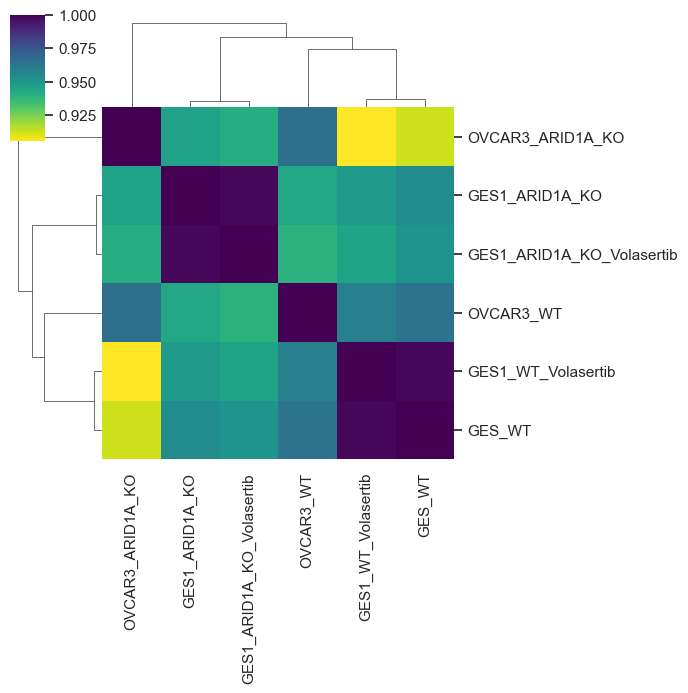

In [34]:
# fig, ax = plt.subplots(figsize=(7,7))
sns.clustermap(corr_mat, figsize=(7,7), cmap='viridis_r', )
# plt.savefig("H:\\Rajeeva\\OneDrive - smail.iitm.ac.in\\Projects\\NUS collaboration\\ARID1A-analysis\\results\\model_evaluation\\gene_expression_correlation_no_objective.svg",
#             dpi=300, bbox_inches='tight')

In [7]:
ge_df.T.index

Index(['GES1_ARID1A_KO', 'GES1_ARID1A_KO_Volasertib', 'GES1_WT_Volasertib',
       'GES_WT', 'OVCAR3_ARID1A_KO', 'OVCAR3_WT'],
      dtype='object')

array([0.52557518, 0.41564494, 0.04582429])

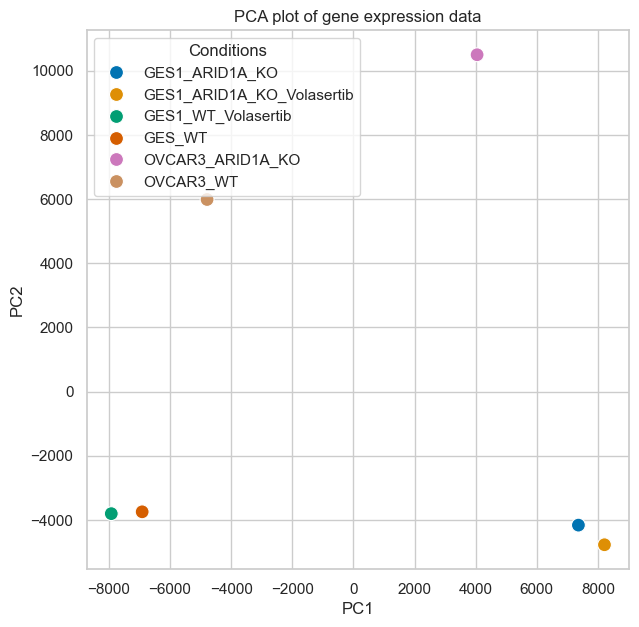

In [54]:
# Small PCA plot too

from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(ge_df.T)

fig, ax = plt.subplots(figsize=(7,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=ge_df.T.index, s=100)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Conditions")
# ax.legend(bbox_to_anchor=(1.05, 1))
ax.set_title("PCA plot of gene expression data")


# plt.savefig("../../results\\model_evaluation\\pca-gene-expression.svg",
#             dpi=300, bbox_inches='tight')

pca.explained_variance_ratio_

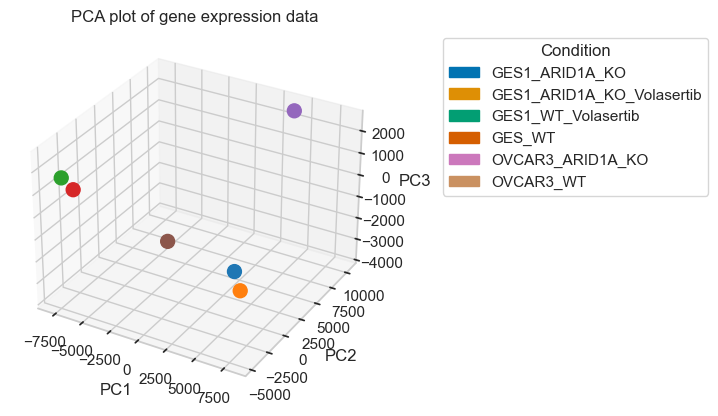

In [59]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

levels, categories = pd.factorize(ge_df.T.index)
colors = [plt.cm.tab10(i) for i in levels]
handles = [mpl.patches.Patch(color=sns.color_palette("colorblind")[i], label=c) for i, c in enumerate(categories)]

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=colors, alpha=1, s=100)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA plot of gene expression data")


ax.legend(handles=handles, title='Condition', bbox_to_anchor=(1.15, 1))

In [56]:
colors

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0)]

# Model Comparisons

In [21]:
rxn_df = pl.read_csv("../../outputs/builtmodels/reaction_presence_absence matrix.csv")
# rxn_df = rxn_df.to_pandas().set_index("Reactions")

In [22]:
rxn_df

Reactions,sprint_GES1_ARID1A_KO,gimme_GES1_ARID1A_KO,init_GES1_ARID1A_KO,sprint_GES1_ARID1A_KO_Volasertib,gimme_GES1_ARID1A_KO_Volasertib,init_GES1_ARID1A_KO_Volasertib,sprint_GES1_WT_Volasertib,gimme_GES1_WT_Volasertib,init_GES1_WT_Volasertib,sprint_GES_WT,gimme_GES_WT,init_GES_WT,sprint_OVCAR3_ARID1A_KO,gimme_OVCAR3_ARID1A_KO,init_OVCAR3_ARID1A_KO,sprint_OVCAR3_WT,gimme_OVCAR3_WT,init_OVCAR3_WT
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""10FTHF5GLUtl""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""10FTHF5GLUtm""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""10FTHF6GLUtl""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""10FTHF6GLUtm""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""10FTHF7GLUtl""",1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CYOR_u10mi""",1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0
"""Htmi""",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"""NADH2_u10mi""",0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,1,1,0


In [23]:
from scipy.spatial.distance import pdist, squareform

[0.27875872 0.2416005  0.1972526 ]
[0.32767679 0.22339694 0.17407679]
[0.28970094 0.24949607 0.20228236]


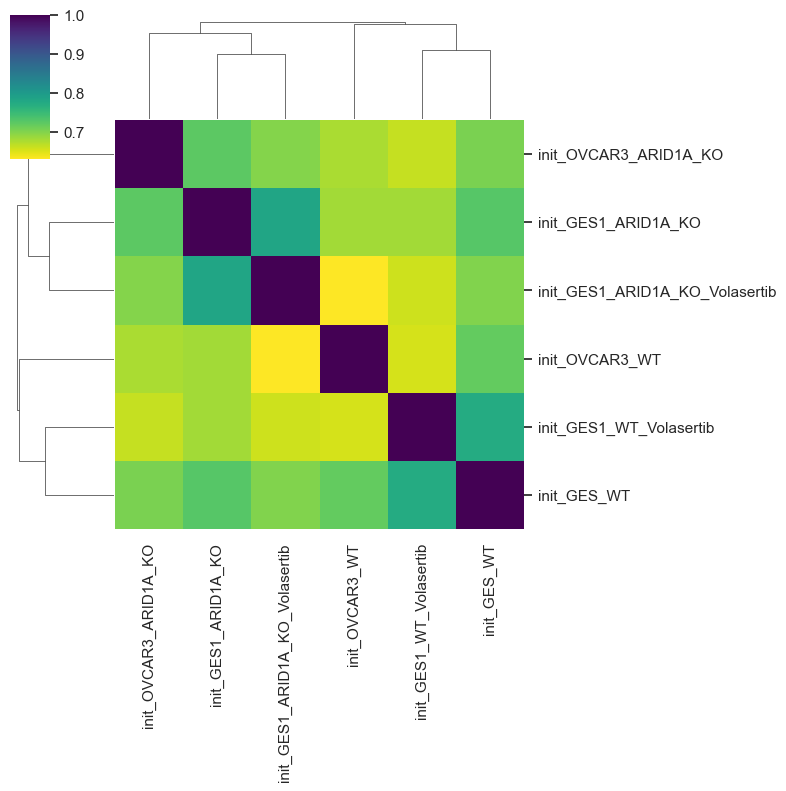

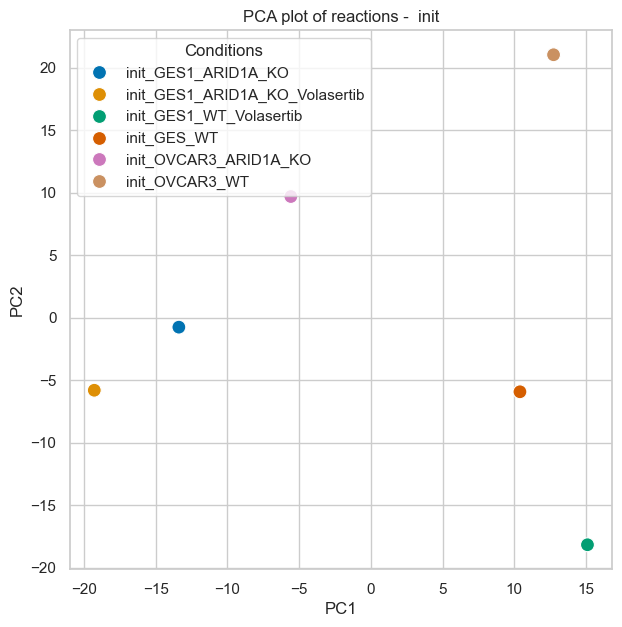

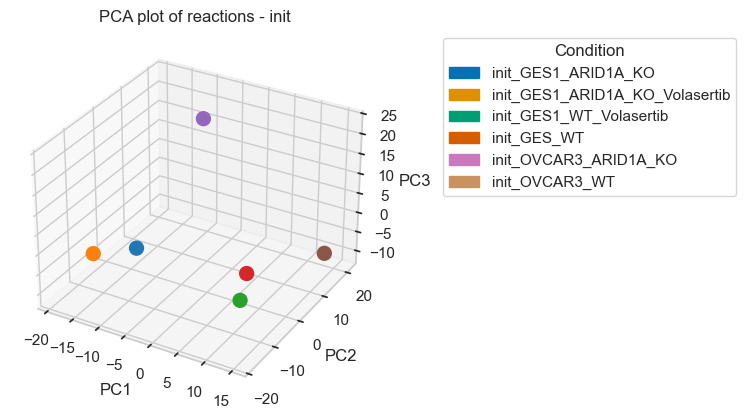

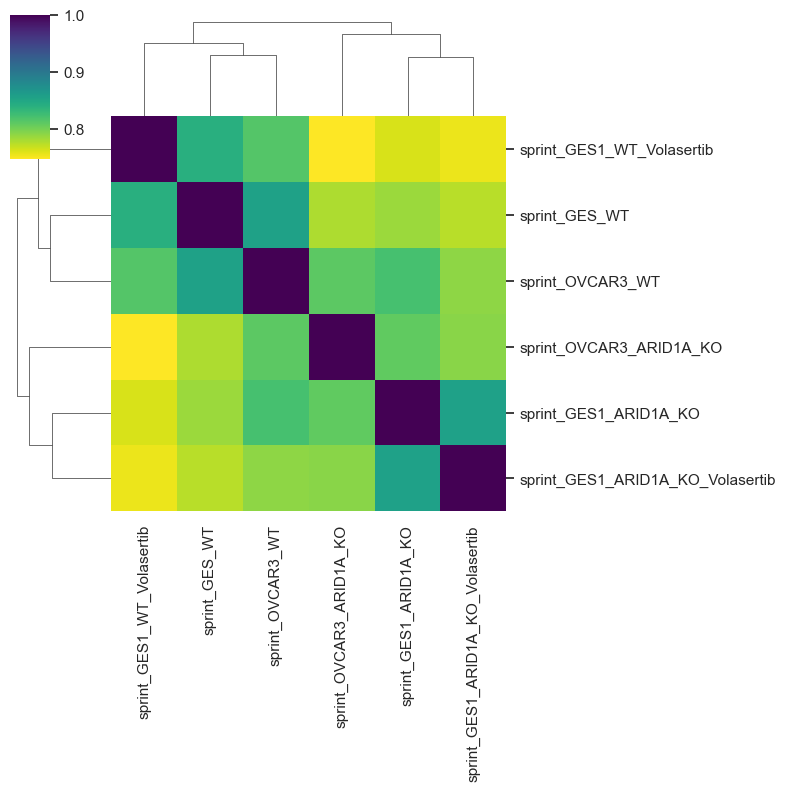

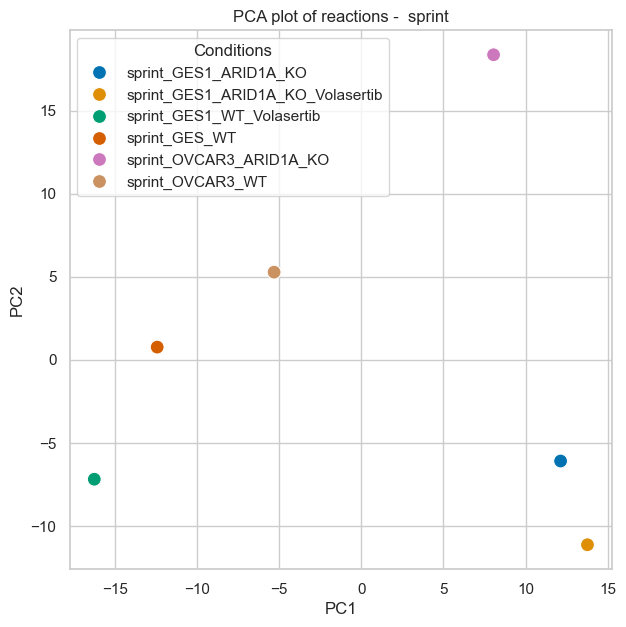

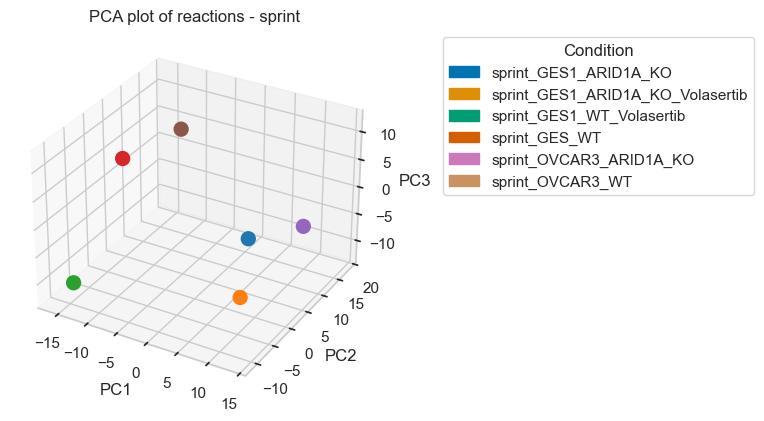

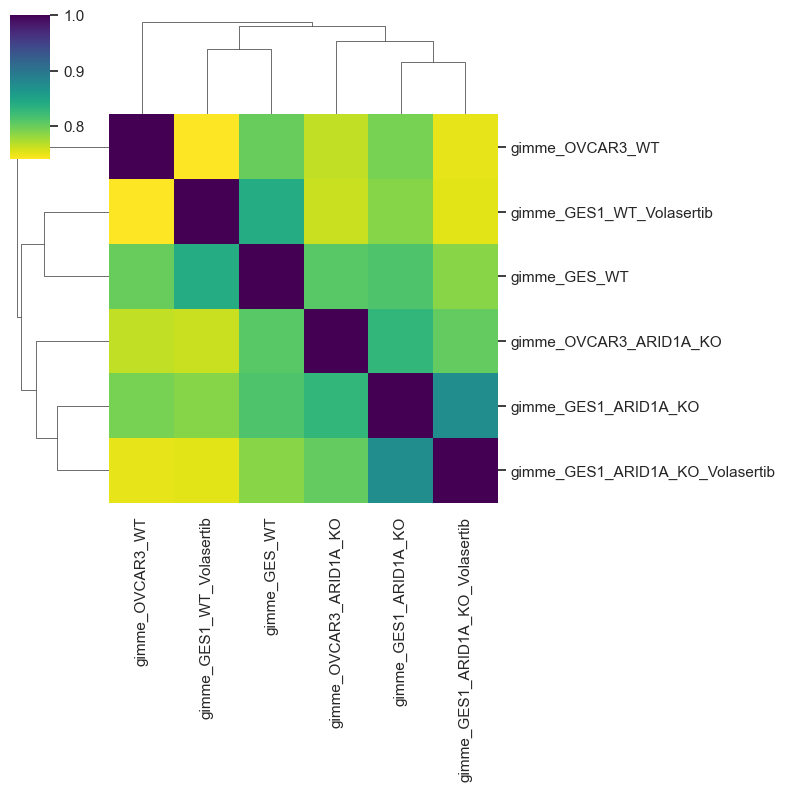

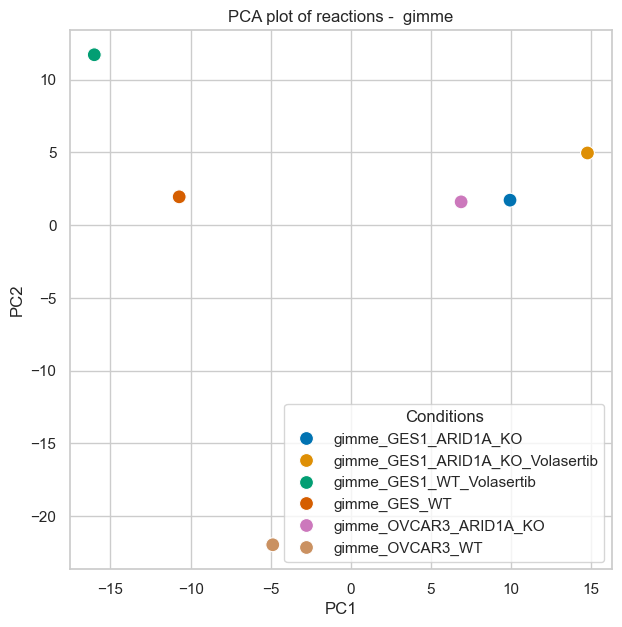

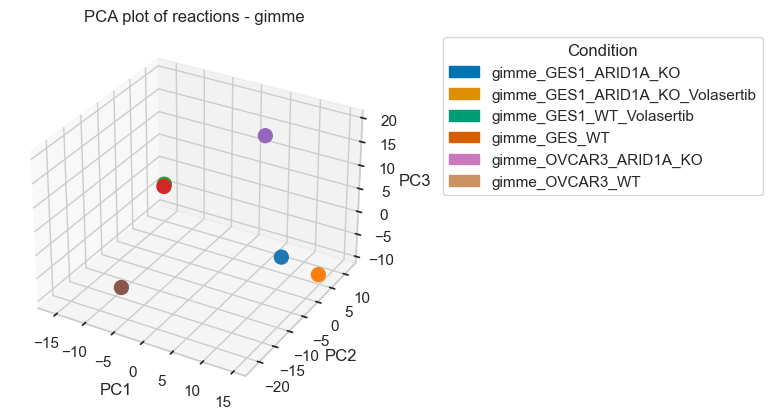

In [60]:
# fig, ax = plt.subplots(1, 3, figsize=(7,7))

corr_mats = []

for algo in ['init', 'sprint', 'gimme']:
    model_df = rxn_df.select(cs.starts_with(algo)).to_pandas()
    # dist = pd.DataFrame(squareform(pdist(model_df.T, metric='jaccard')), columns=model_df.columns, index=model_df.columns)
    corr_mat_model = model_df.corr()
    corr_mats.append(corr_mat_model)
    sns.clustermap(corr_mat_model, figsize=(8,8), cmap="viridis_r", )
    # plt.savefig(f"../../results/model_evaluation/jaccard_dist_{algo}.svg", dpi=300, bbox_inches='tight')
    
    # PCA for algorithms
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(model_df.T)

    fig, ax = plt.subplots(figsize=(7,7))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=model_df.T.index, s=100)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Conditions")
    # ax.legend(bbox_to_anchor=(1.05, 1))
    ax.set_title(f"PCA plot of reactions -  {algo}")
    
    # plt.savefig(f"../../results/model_evaluation/pca-{algo}.svg", dpi=300, bbox_inches='tight')
    
    print(pca.explained_variance_ratio_)
    
    
    fig2 = plt.figure()
    ax_3d = fig2.add_subplot(111, projection='3d')
    

    levels, categories = pd.factorize(model_df.T.index)
    colors = [plt.cm.tab10(i) for i in levels]
    handles = [mpl.patches.Patch(color=sns.color_palette("colorblind")[i], label=c) for i, c in enumerate(categories)]

    ax_3d.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=colors, alpha=1, s=100)
    ax_3d.set_xlabel("PC1")
    ax_3d.set_ylabel("PC2")
    ax_3d.set_zlabel("PC3")
    ax_3d.set_title(f"PCA plot of reactions - {algo}")


    ax_3d.legend(handles=handles, title='Condition', bbox_to_anchor=(1.15, 1))

In [16]:
corr_mat

,GES1_ARID1A_KO,GES1_ARID1A_KO_Volasertib,GES1_WT_Volasertib,GES_WT,OVCAR3_ARID1A_KO,OVCAR3_WT
GES1_ARID1A_KO,1.000000,0.998162,0.949150,0.954582,0.945794,0.943691
GES1_ARID1A_KO_Volasertib,0.998162,1.000000,0.945233,0.951034,0.941613,0.939590
GES1_WT_Volasertib,0.949150,0.945233,1.000000,0.998357,0.905700,0.959319
GES_WT,0.954582,0.951034,0.998357,1.000000,0.912879,0.963970
OVCAR3_ARID1A_KO,0.945794,0.941613,0.905700,0.912879,1.000000,0.965819
OVCAR3_WT,0.943691,0.939590,0.959319,0.963970,0.965819,1.000000


In [17]:
corr_mats[0]

,init_GES1_ARID1A_KO,init_GES1_ARID1A_KO_Volasertib,init_GES1_WT_Volasertib,init_GES_W1,init_OVCAR3_ARID1A_KO,init_OVCAR3_WT
init_GES1_ARID1A_KO,1.000000,0.782904,0.682991,0.729254,0.725073,0.683471
init_GES1_ARID1A_KO_Volasertib,0.782904,1.000000,0.659091,0.701468,0.700336,0.631708
init_GES1_WT_Volasertib,0.682991,0.659091,1.000000,0.775153,0.663387,0.654854
init_GES_W1,0.729254,0.701468,0.775153,1.000000,0.706208,0.720832
init_OVCAR3_ARID1A_KO,0.725073,0.700336,0.663387,0.706208,1.000000,0.677903
init_OVCAR3_WT,0.683471,0.631708,0.654854,0.720832,0.677903,1.000000


In [18]:
corr_mats[1]

,sprint_GES1_ARID1A_KO,sprint_GES1_ARID1A_KO_Volasertib,sprint_GES1_WT_Volasertib,sprint_GES_W1,sprint_OVCAR3_ARID1A_KO,sprint_OVCAR3_WT
sprint_GES1_ARID1A_KO,1.000000,0.848057,0.743498,0.780505,0.811691,0.817741
sprint_GES1_ARID1A_KO_Volasertib,0.848057,1.000000,0.751063,0.774107,0.794324,0.782091
sprint_GES1_WT_Volasertib,0.743498,0.751063,1.000000,0.825022,0.737356,0.807136
sprint_GES_W1,0.780505,0.774107,0.825022,1.000000,0.779674,0.864362
sprint_OVCAR3_ARID1A_KO,0.811691,0.794324,0.737356,0.779674,1.000000,0.810403
sprint_OVCAR3_WT,0.817741,0.782091,0.807136,0.864362,0.810403,1.000000


In [19]:
np.sum((corr_mat.values - corr_mats[0].values)**2)

1.9350149524693285

In [20]:
np.sum((corr_mat.values - corr_mats[1].values)**2)


0.7556875000163741

# Task based evaluation

In [2]:
data_path = Path('../../results/model_evaluation/no_objective_tasks/')

files = list(data_path.glob("*.csv"))

In [3]:
result_dict = dict()

for file in files:
    df = pd.read_csv(file, header=None)
    result_dict[file.stem] = eval(df.iloc[-2,4])

In [4]:
list(filter(lambda x: 'init' in x[0], result_dict.items()))

[('init_GES1_ARID1A_KO', 0.6476190476190476),
 ('init_GES1_ARID1A_KO_Volasertib', 0.6476190476190476),
 ('init_GES1_WT_Volasertib', 0.6476190476190476),
 ('init_GES_W1', 0.580952380952381),
 ('init_OVCAR3_ARID1A_KO', 0.6285714285714286),
 ('init_OVCAR3_WT', 0.5142857142857142)]

In [5]:
list(filter(lambda x: 'sprint' in x[0], result_dict.items()))

[('sprint_GES1_ARID1A_KO', 0.7523809523809524),
 ('sprint_GES1_ARID1A_KO_Volasertib', 0.7333333333333333),
 ('sprint_GES1_WT_Volasertib', 0.7380952380952381),
 ('sprint_GES_W1', 0.7047619047619048),
 ('sprint_OVCAR3_ARID1A_KO', 0.7619047619047619),
 ('sprint_OVCAR3_WT', 0.7142857142857143)]

In [6]:
data_path = Path('../../results/model_evaluation/objective_tasks/')

files = list(data_path.glob("*.csv"))

result_dict = dict()

for file in files:
    df = pd.read_csv(file, header=None)
    result_dict[file.stem] = eval(df.iloc[-2,4])

In [7]:
list(filter(lambda x: 'sprint' in x[0], result_dict.items()))


[('sprint_GES1_ARID1A_KO', 0.7428571428571429),
 ('sprint_GES1_ARID1A_KO_Volasertib', 0.7),
 ('sprint_GES1_WT_Volasertib', 0.7),
 ('sprint_GES_WT', 0.7047619047619048),
 ('sprint_OVCAR3_ARID1A_KO', 0.7523809523809524),
 ('sprint_OVCAR3_WT', 0.7142857142857143)]

In [8]:
list(filter(lambda x: 'gimme' in x[0], result_dict.items()))

[('gimme_GES1_ARID1A_KO', 0.3904761904761905),
 ('gimme_GES1_ARID1A_KO_Volasertib', 0.38571428571428573),
 ('gimme_GES1_WT_Volasertib', 0.48095238095238096),
 ('gimme_GES_WT', 0.44761904761904764),
 ('gimme_OVCAR3_ARID1A_KO', 0.5142857142857142),
 ('gimme_OVCAR3_WT', 0.3619047619047619)]

In [9]:
list(filter(lambda x: 'init' in x[0], result_dict.items()))


[('init_GES1_ARID1A_KO', 0.6571428571428571),
 ('init_GES1_ARID1A_KO_Volasertib', 0.638095238095238),
 ('init_GES1_WT_Volasertib', 0.6619047619047619),
 ('init_GES_WT', 0.580952380952381),
 ('init_OVCAR3_ARID1A_KO', 0.6238095238095238),
 ('init_OVCAR3_WT', 0.5095238095238095)]

In [10]:
df

,0,1,2,3,4
0,1,ENERGY METABOLISM,OXYDATIVE PHOSPHORYLATION,Oxidative phosphorylation via NADH-coenzyme Q ...,true
1,2,ENERGY METABOLISM,OXYDATIVE PHOSPHORYLATION,Oxidative phosphorylation via succinate-coenzy...,true
2,3,ENERGY METABOLISM,KREBS CYCLE,Krebs cycle - oxidative decarboxylation of pyr...,true
3,4,ENERGY METABOLISM,KREBS CYCLE,Krebs cycle - NADH generation,true
4,5,ENERGY METABOLISM,ATP GENERATION,ATP regeneration from glucose (normoxic condit...,true
...,...,...,...,...,...
207,208,GLYCAN METABOLISM,KERATAN SULFATE METABOLISM,Keratan sulfate biosynthesis from O-glycan (co...,true
208,209,GLYCAN METABOLISM,KERATAN SULFATE METABOLISM,Keratan sulfate degradation,true
209,210,GLYCAN METABOLISM,KERATAN SULFATE METABOLISM,Keratan sulfate biosynthesis from N-glycan,FAIL (should NOT fail)
210,Final Score,NaN,NaN,NaN,150/210
